In [4]:
import os
import json
import pandas as pd
from pydub import AudioSegment

audio_root = "/Users/annsleyshee/Desktop/SLR-model/Clean_Audio"
durations = []
corrupt_audio = []

for root, _, files in os.walk(audio_root):
    for file in files:
        if file.endswith((".mp3", ".flac", ".wav")):
            try:
                audio = AudioSegment.from_file(os.path.join(root, file))
                duration = len(audio) / 1000  # milliseconds to seconds
                durations.append(duration)
            except Exception as e:
                corrupt_audio.append((audio_path, str(e)))

# Summary
if durations:
    df = pd.DataFrame(durations, columns = ["duration_seconds"])
    print("Statistics of Audio Datasets")
    print(df.describe())
else:
    print("No valid audio files found.")
    
if corrupt_audio:
    print(f"Corrupted Audios: {len(corrupt_audio)}")

Statistics of Audio Datasets
       duration_seconds
count        358.000000
mean           8.555492
std            2.459558
min            0.055000
25%            7.416000
50%           10.000000
75%           10.000000
max           10.000000


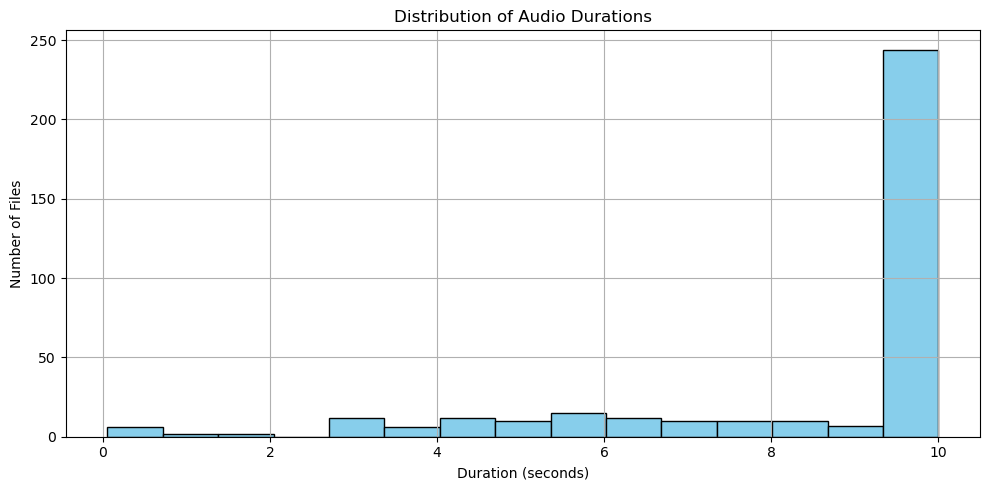

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.hist(df["duration_seconds"], bins=15, color='skyblue', edgecolor='black')
plt.title("Distribution of Audio Durations")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.grid(True)
plt.tight_layout()
plt.show()


In [18]:
import os
import pandas as pd
from pydub import AudioSegment

# Set your dataset path
audio_root = "/Users/annsleyshee/Desktop/SLR-model/Clean_Audio"

# Prepare lists
file_paths = []
durations = []
volumes = []
silent_files = []
corrupt_files = []

# Loop through files
for root, _, files in os.walk(audio_root):
    for file in files:
        if file.endswith((".mp3", ".flac", ".wav")):
            audio_path = os.path.join(root, file)
            try:
                audio = AudioSegment.from_file(audio_path)

                duration = len(audio) / 1000  # in seconds
                volume = audio.dBFS

                # Store results
                file_paths.append(audio_path)
                durations.append(duration)
                volumes.append(volume)

                if volume == float("-inf"):
                    silent_files.append(audio_path)

            except Exception as e:
                corrupt_files.append((audio_path, str(e)))

# Create DataFrame
df = pd.DataFrame({
    "file_path": file_paths,
    "duration_seconds": durations,
    "volume_dBFS": volumes
})

# Summary
df_non_silent = df[df["volume_dBFS"] > float("-inf")]

# Summary without silent files
print("\nVolume Summary (excluding silent files)")
print(df_non_silent["volume_dBFS"].describe())

print(f"\n🔇 Silent files: {len(silent_files)}")
print(f"⚠️ Corrupted files: {len(corrupt_files)}")

# Optional: Save results
df.to_csv("audio_summary.csv", index=False)

# Save silent file paths
with open("silent_files.txt", "w") as f:
    for path in silent_files:
        f.write(path + "\n")

# Save corrupted file logs
with open("corrupt_files.txt", "w") as f:
    for path, error in corrupt_files:
        f.write(f"{path} - {error}\n")



Volume Summary (excluding silent files)
count    351.000000
mean     -27.456833
std        5.041876
min      -71.224149
25%      -27.612795
50%      -26.313895
75%      -25.261648
max      -20.263188
Name: volume_dBFS, dtype: float64

🔇 Silent files: 7
⚠️ Corrupted files: 0


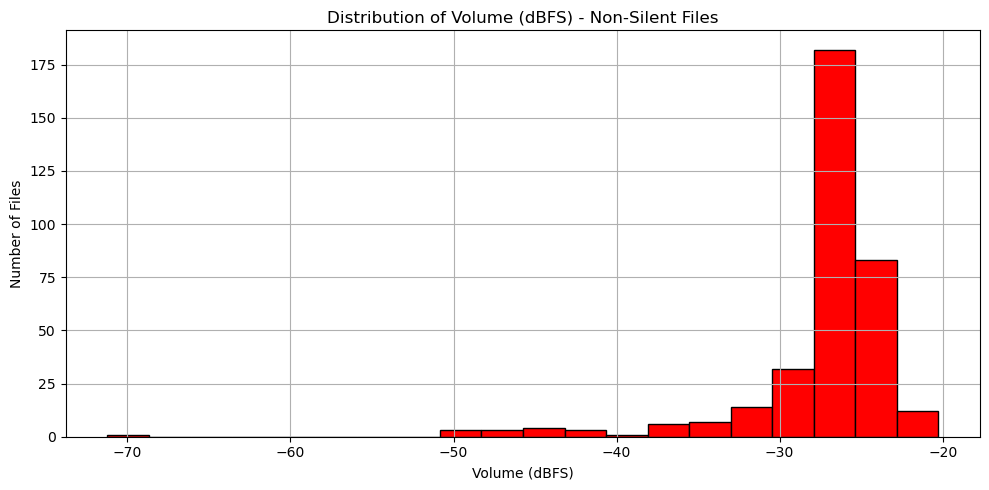

In [21]:
import matplotlib.pyplot as plt

# Plot volume distribution
plt.figure(figsize=(10, 5))
plt.hist(df_non_silent["volume_dBFS"], bins=20, color="red", edgecolor="black")
plt.title("Distribution of Volume (dBFS) - Non-Silent Files")
plt.xlabel("Volume (dBFS)")
plt.ylabel("Number of Files")
plt.grid(True)
plt.tight_layout()
plt.show()


In [24]:
!pip install librosa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.7/260.7 kB 2.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.6/64.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 1.6 MB/s eta 0:00:0000:0100:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.4/156.4 kB 1.6 MB/s eta 0:00:00a 0:00:01


In [35]:
import librosa
import numpy as np
import pandas as pd

# Make sure df_non_silent already exists and contains a 'file_path' column

# Step 1: Extract pitch for each file
pitch_values = []

for path in df_non_silent["file_path"]:
    try:
        y, sr = librosa.load(path)
        pitches, magnitudes = librosa.piptrack(y=y, sr=sr)
        pitch = pitches[magnitudes > np.mean(magnitudes)]  # filter weak signals
        mean_pitch = pitch.mean() if len(pitch) > 0 else np.nan
        pitch_values.append(mean_pitch)
    except Exception as e:
        pitch_values.append(np.nan)

# Step 2: Add to DataFrame (ensure numeric type)
df_non_silent = df_non_silent.reset_index(drop=True)  # safe reset
df_non_silent["pitch_Hz"] = pd.to_numeric(pitch_values, errors='coerce')

# Step 3: Summary
print("\nPitch Summary (Hz)")
print(df_non_silent["pitch_Hz"].dropna().describe())



Pitch Summary (Hz)
count     351.000000
mean     1671.855522
std       246.002178
min       654.153015
25%      1560.994080
50%      1714.069214
75%      1795.882568
max      3649.237305
Name: pitch_Hz, dtype: float64


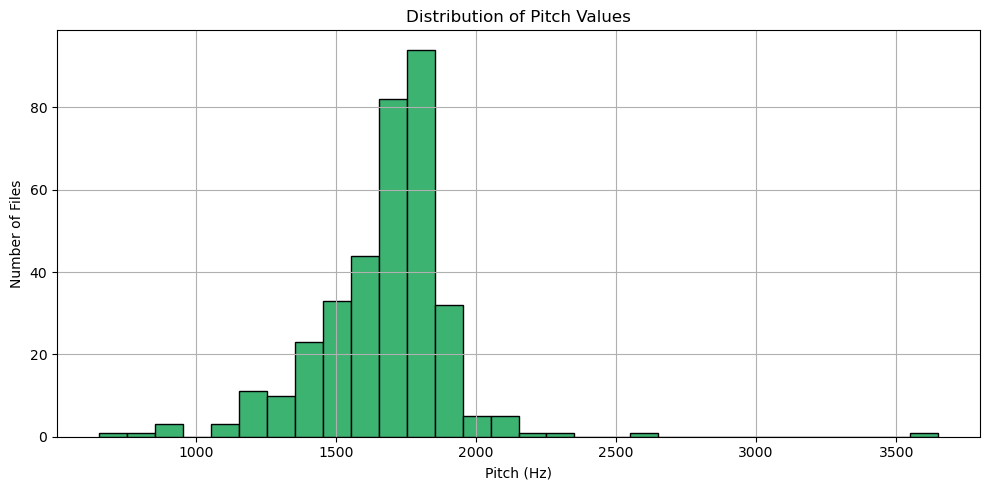

In [37]:
import matplotlib.pyplot as plt

# Drop NaNs from pitch column
pitch_data = df_non_silent["pitch_Hz"].dropna()

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(pitch_data, bins=30, color='mediumseagreen', edgecolor='black')

plt.title("Distribution of Pitch Values")
plt.xlabel("Pitch (Hz)")
plt.ylabel("Number of Files")
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
from librosa.beat import tempo
from librosa.onset import onset_detect

speaker_rates = []

for path in df_non_silent["file_path"]:
    try:
        y, sr = librosa.load(path)
        onset_frames = onset_detect(y=y, sr=sr)
        onset_times = librosa.frames_to_time(onset_frames, sr=sr)
        
        duration = librosa.get_duration(y=y, sr=sr)
        rate = len(onset_times) / duration if duration > 0 else np.nan  # rough syllables/sec
        speaker_rates.append(rate)
    except Exception as e:
        speaker_rates.append(np.nan)

df_non_silent["speaker_rate"] = pd.to_numeric(speaker_rates, errors='coerce')


In [45]:
from librosa.effects import split

speech_ratios = []

for path in df_non_silent["file_path"]:
    try:
        y, sr = librosa.load(path)
        intervals = split(y, top_db=30)  # voice activity regions
        total_speech_duration = sum((end - start) for start, end in intervals) / sr
        total_duration = librosa.get_duration(y=y, sr=sr)
        ratio = total_speech_duration / total_duration if total_duration > 0 else np.nan
        speech_ratios.append(ratio)
    except Exception as e:
        speech_ratios.append(np.nan)

df_non_silent["speech_ratio"] = pd.to_numeric(speech_ratios, errors='coerce')


In [46]:
print("\nSpeaker Rate Summary")
print(df_non_silent["speaker_rate"].dropna().describe())

print("\nSpeech Ratio Summary")
print(df_non_silent["speech_ratio"].dropna().describe())



Speaker Rate Summary
count    351.000000
mean       4.485212
std        1.170391
min        1.100000
25%        3.815705
50%        4.700000
75%        5.400000
max        6.800000
Name: speaker_rate, dtype: float64

Speech Ratio Summary
count    351.000000
mean       0.670920
std        0.177964
min        0.141642
25%        0.512361
50%        0.726785
75%        0.819664
max        0.928018
Name: speech_ratio, dtype: float64


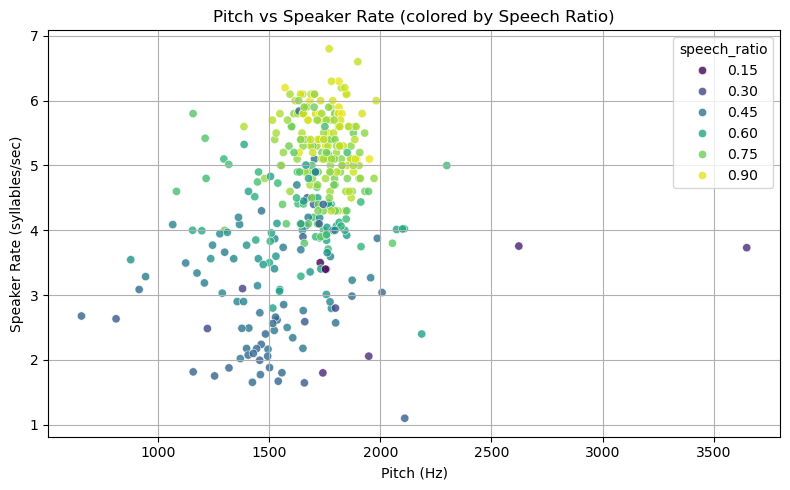

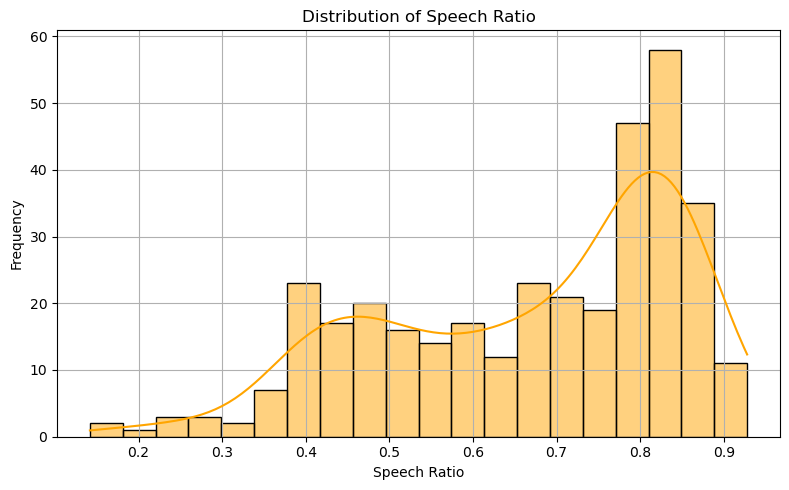

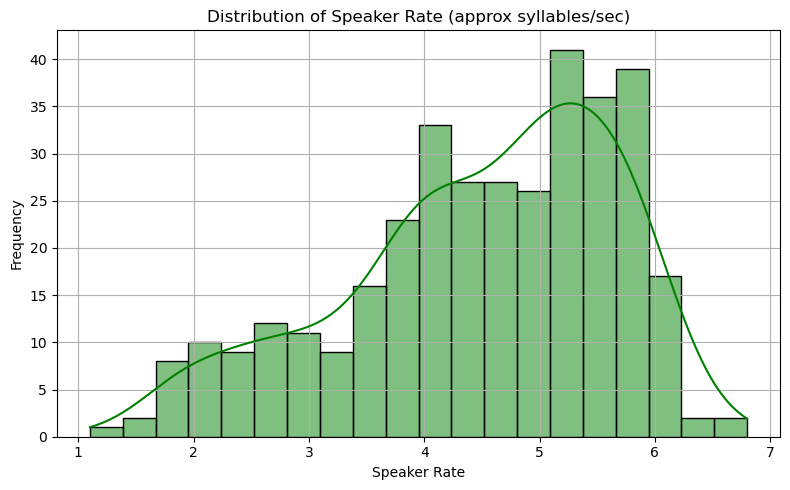

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure df_non_silent exists and has relevant columns: pitch_Hz, speaker_rate, speech_ratio
df_plot = df_non_silent.dropna(subset=["pitch_Hz", "speaker_rate", "speech_ratio"])

# Plot 1: Scatter Plot - Pitch vs Speaker Rate, colored by Speech Ratio
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df_plot,
    x="pitch_Hz",
    y="speaker_rate",
    hue="speech_ratio",
    palette="viridis",
    alpha=0.8
)
plt.title("Pitch vs Speaker Rate (colored by Speech Ratio)")
plt.xlabel("Pitch (Hz)")
plt.ylabel("Speaker Rate (syllables/sec)")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Histogram - Speech Ratio Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df_plot["speech_ratio"], bins=20, kde=True, color='orange')
plt.title("Distribution of Speech Ratio")
plt.xlabel("Speech Ratio")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: Histogram - Speaker Rate
plt.figure(figsize=(8, 5))
sns.histplot(df_plot["speaker_rate"], bins=20, kde=True, color='green')
plt.title("Distribution of Speaker Rate (approx syllables/sec)")
plt.xlabel("Speaker Rate")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()
